In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../datasets/results.csv")

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [3]:
df.shape

(49287, 9)

In [4]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [5]:
df["date"] = pd.to_datetime(df["date"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49287 non-null  datetime64[us]
 1   home_team   49287 non-null  str           
 2   away_team   49287 non-null  str           
 3   home_score  49215 non-null  float64       
 4   away_score  49215 non-null  float64       
 5   tournament  49287 non-null  str           
 6   city        49287 non-null  str           
 7   country     49287 non-null  str           
 8   neutral     49287 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(5)
memory usage: 3.1 MB


In [7]:
df["total_goals"] = df["home_score"] + df["away_score"]

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,6.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,3.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,4.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,3.0


In [8]:
df["winner"] = df.apply(
    lambda x: x["home_team"]
    if x["home_score"] > x["away_score"]
    else (
        x["away_team"]
        if x["away_score"] > x["home_score"]
        else "Draw"
    ),
    axis=1
)

In [9]:
df["year"] = df["date"].dt.year

In [10]:
goals_per_year = df.groupby("year")["total_goals"].mean()

In [11]:
df = df.dropna(subset=["home_score", "away_score"])

In [12]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score     0
away_score     0
tournament     0
city           0
country        0
neutral        0
total_goals    0
winner         0
year           0
dtype: int64

In [13]:
df["date"] = pd.to_datetime(df["date"])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49215 entries, 0 to 49214
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         49215 non-null  datetime64[us]
 1   home_team    49215 non-null  str           
 2   away_team    49215 non-null  str           
 3   home_score   49215 non-null  float64       
 4   away_score   49215 non-null  float64       
 5   tournament   49215 non-null  str           
 6   city         49215 non-null  str           
 7   country      49215 non-null  str           
 8   neutral      49215 non-null  bool          
 9   total_goals  49215 non-null  float64       
 10  winner       49215 non-null  str           
 11  year         49215 non-null  int32         
dtypes: bool(1), datetime64[us](1), float64(3), int32(1), str(6)
memory usage: 4.0 MB


In [15]:
df["winner"] = df.apply(
    lambda x:
    x["home_team"]
    if x["home_score"] > x["away_score"]
    else (
        x["away_team"]
        if x["away_score"] > x["home_score"]
        else "Draw"
    ),
    axis=1
)


In [16]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,winner,year
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0.0,Draw,1872
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,6.0,England,1873
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,3.0,Scotland,1874
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,4.0,Draw,1875
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,3.0,Scotland,1876


In [17]:
top_wins = df["winner"].value_counts().head(10)

top_wins

winner
Draw           11197
Brazil           670
England          623
Germany          597
Argentina        588
Sweden           541
South Korea      536
Mexico           511
France           476
Italy            475
Name: count, dtype: int64

In [18]:
top_wins = df[df["winner"] != "Draw"]["winner"] \
    .value_counts() \
    .head(10)

In [19]:
home_goals = df.groupby("home_team")["home_score"].sum()

away_goals = df.groupby("away_team")["away_score"].sum()

total_country_goals = home_goals.add(
    away_goals,
    fill_value=0
)

top_scoring = total_country_goals.sort_values(
    ascending=False
).head(10)

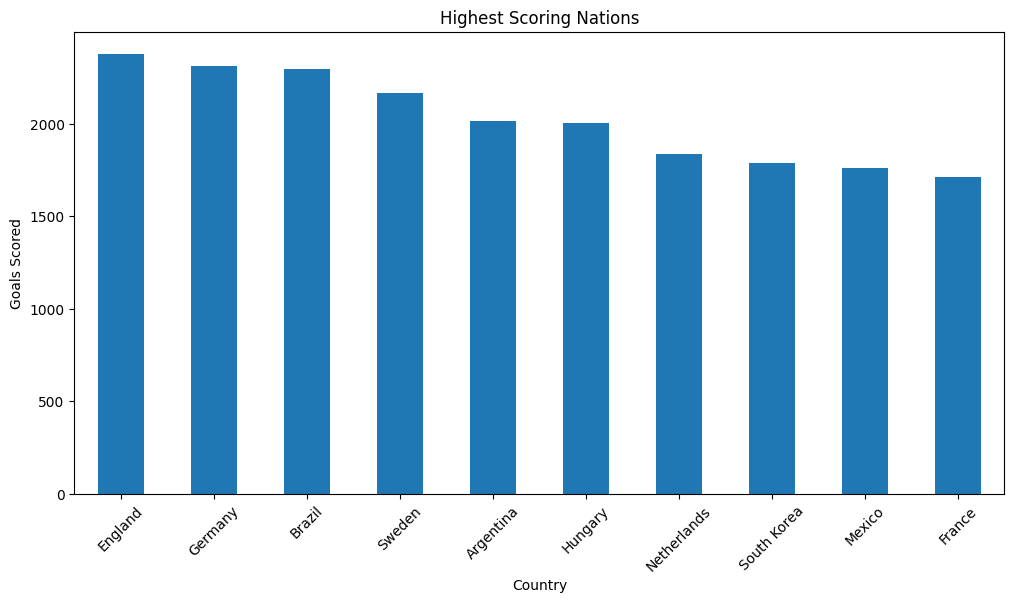

In [20]:
plt.figure(figsize=(12,6))

top_scoring.plot(kind="bar")

plt.title("Highest Scoring Nations")
plt.xlabel("Country")
plt.ylabel("Goals Scored")

plt.xticks(rotation=45)

plt.savefig("../charts/highest_scoring_nations.png")

plt.show()

In [21]:
df["year"] = df["date"].dt.year

In [22]:
goals_per_year = df.groupby("year")["total_goals"].mean()

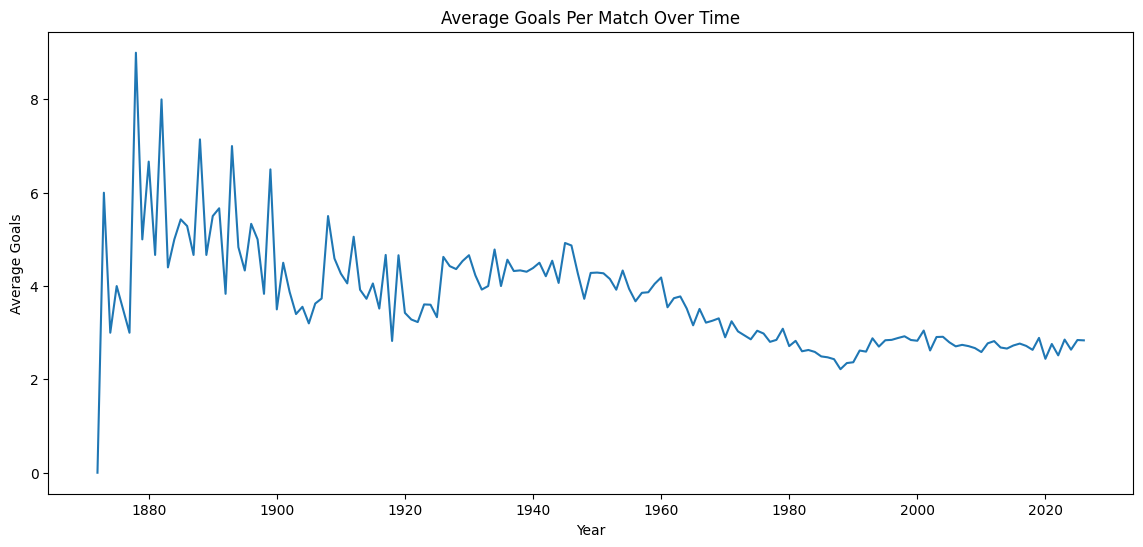

In [23]:
plt.figure(figsize=(14,6))

goals_per_year.plot()

plt.title("Average Goals Per Match Over Time")
plt.xlabel("Year")
plt.ylabel("Average Goals")

plt.savefig("../charts/goals_over_time.png")

plt.show()

## Insights

- Goal averages fluctuate significantly across eras.
- Older football eras often had higher scoring matches.
- Modern football appears more tactically balanced.

In [24]:
home_goals = df.groupby("home_team")["home_score"].sum()

away_goals = df.groupby("away_team")["away_score"].sum()

total_country_goals = home_goals.add(
    away_goals,
    fill_value=0
)

top_scoring = total_country_goals.sort_values(
    ascending=False
).head(10)

top_scoring

home_team
England        2377.0
Germany        2314.0
Brazil         2297.0
Sweden         2168.0
Argentina      2016.0
Hungary        2006.0
Netherlands    1839.0
South Korea    1786.0
Mexico         1759.0
France         1711.0
dtype: float64

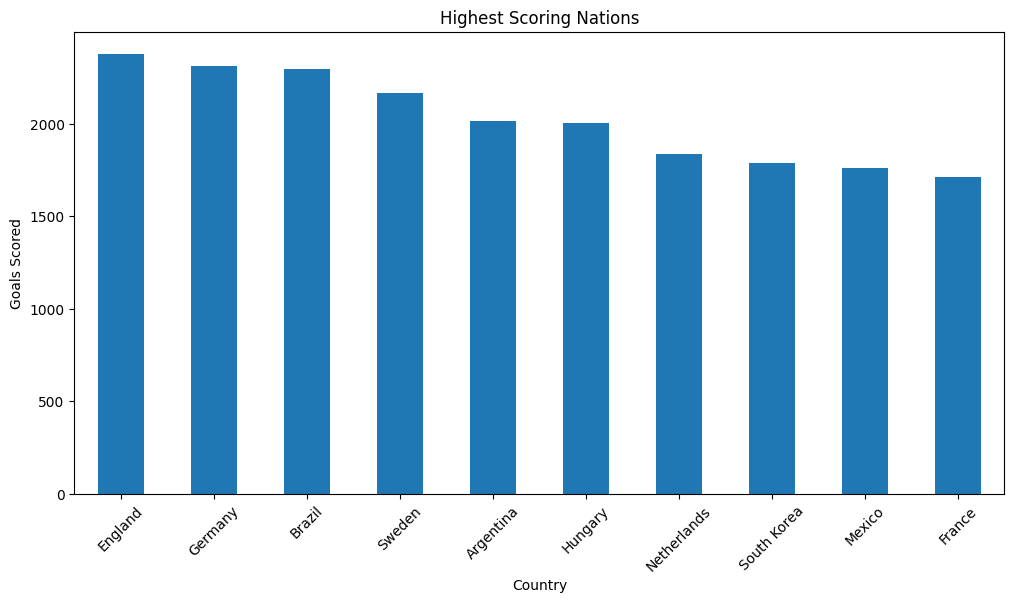

In [25]:
plt.figure(figsize=(12,6))

top_scoring.plot(kind="bar")

plt.title("Highest Scoring Nations")
plt.xlabel("Country")
plt.ylabel("Goals Scored")

plt.xticks(rotation=45)

plt.savefig("../charts/highest_scoring_nations.png")

plt.show()

In [26]:
df["decade"] = (df["year"] // 10) * 10

In [27]:
decade_goals = df.groupby("decade")[
    "total_goals"
].mean()

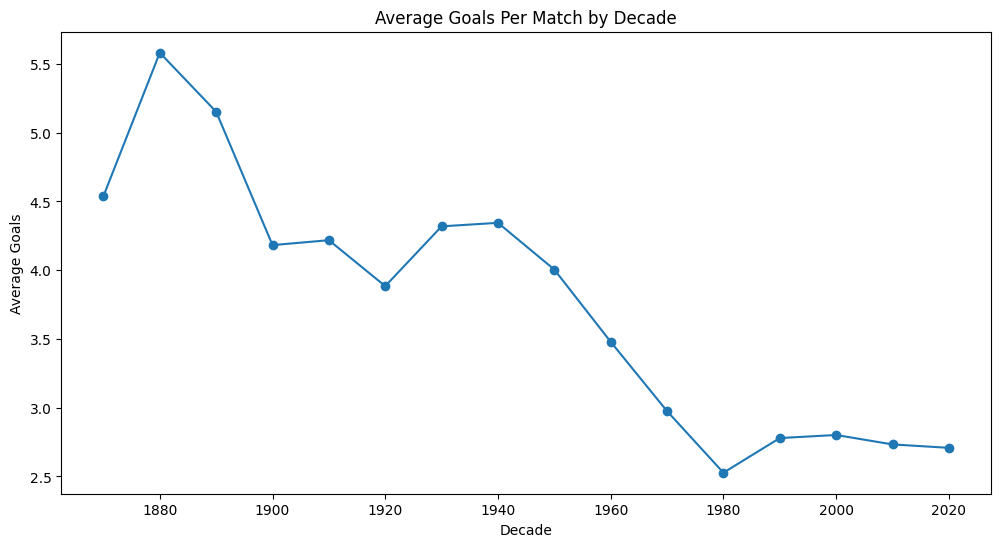

In [28]:
plt.figure(figsize=(12,6))

decade_goals.plot(marker="o")

plt.title("Average Goals Per Match by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Goals")

plt.savefig("../charts/goals_by_decade.png")

plt.show()

In [29]:
world_cup = df[
    df["tournament"] == "FIFA World Cup"
]

In [30]:
wc_wins = world_cup[
    world_cup["winner"] != "Draw"
]["winner"].value_counts().head(10)

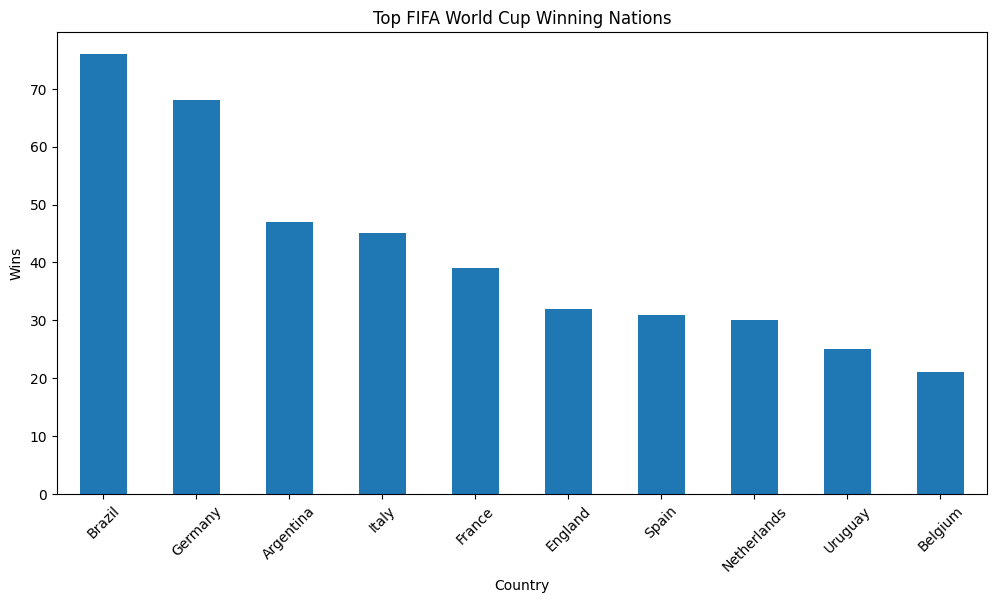

In [31]:
plt.figure(figsize=(12,6))

wc_wins.plot(kind="bar")

plt.title("Top FIFA World Cup Winning Nations")
plt.xlabel("Country")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.savefig("../charts/world_cup_wins.png")

plt.show()

In [32]:
home_wins = (
    df["winner"] == df["home_team"]
).sum()

total_matches = len(df)

home_win_percentage = (
    home_wins / total_matches
) * 100

print(home_win_percentage)

48.98100172711572


In [33]:
neutral_counts = df["neutral"].value_counts()

neutral_counts

neutral
False    36239
True     12976
Name: count, dtype: int64

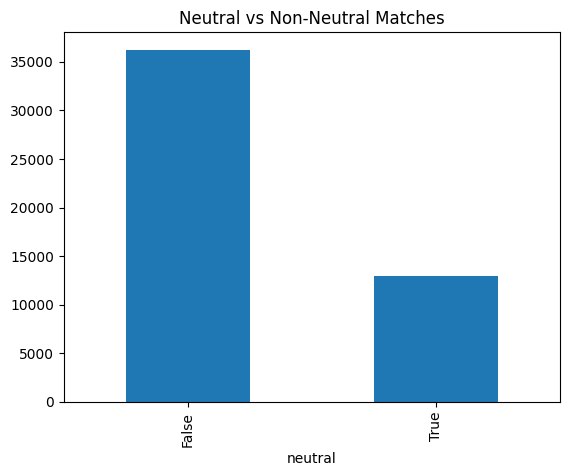

In [34]:
neutral_counts.plot(kind="bar")

plt.title("Neutral vs Non-Neutral Matches")

plt.savefig("../charts/neutral_matches.png")

plt.show()

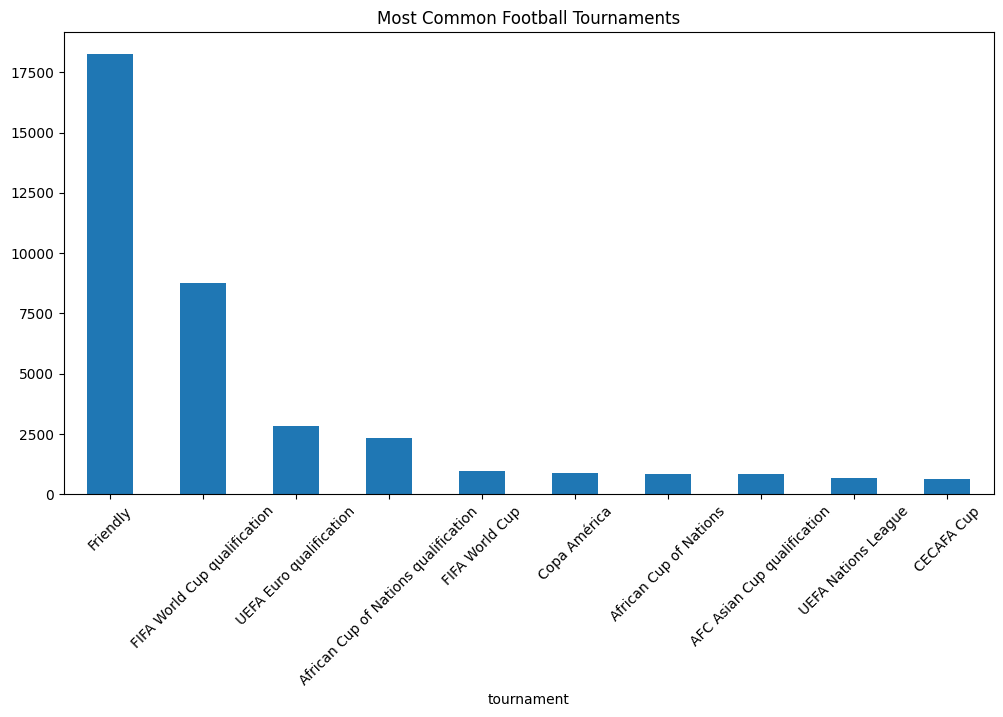

In [35]:
top_tournaments = df[
    "tournament"
].value_counts().head(10)

top_tournaments.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Most Common Football Tournaments")

plt.xticks(rotation=45)

plt.savefig("../charts/top_tournaments.png")

plt.show()

In [36]:
highest_matches = df.sort_values(
    by="total_goals",
    ascending=False
)

highest_matches[
    [
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "total_goals",
        "tournament"
    ]
].head(10)

,home_team,away_team,home_score,away_score,total_goals,tournament
25420,Australia,American Samoa,31.0,0.0,31.0,FIFA World Cup qualification
8547,Tahiti,Cook Islands,30.0,0.0,30.0,South Pacific Games
11912,Fiji,Kiribati,24.0,0.0,24.0,South Pacific Games
30513,Sápmi,Monaco,21.0,1.0,22.0,Viva World Cup
25417,Australia,Tonga,22.0,0.0,22.0,FIFA World Cup qualification
29040,Guam,North Korea,0.0,21.0,21.0,EAFF Championship
21953,Kazakhstan,Guam,20.0,1.0,21.0,East Asian Games
6576,Libya,Oman,21.0,0.0,21.0,Arab Cup
37758,Darfur,Padania,0.0,20.0,20.0,CONIFA World Football Cup
24177,Kuwait,Bhutan,20.0,0.0,20.0,AFC Asian Cup qualification


In [37]:
corr = df[
    [
        "home_score",
        "away_score",
        "total_goals"
    ]
].corr()

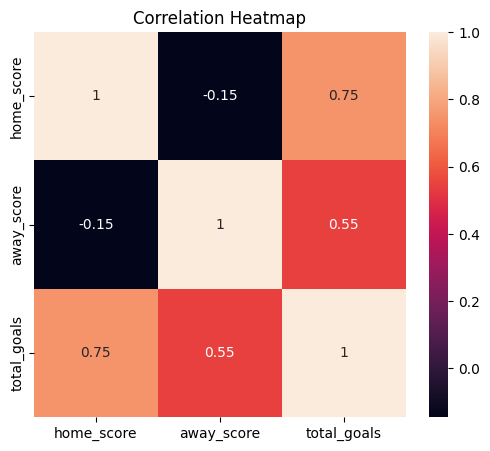

In [38]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.savefig("../charts/correlation_heatmap.png")

plt.show()

In [39]:
df.to_csv("../datasets/cleaned_results.csv", index=False)